## Imports

In [13]:
from dm_control import mjcf,mujoco
import PIL.Image

import copy
import os
import itertools
from IPython.display import clear_output
import numpy as np

%matplotlib inline

# Graphics-related
import matplotlib
import matplotlib.animation as animation
import matplotlib.pyplot as plt
from IPython import display
import PIL.Image

from tempfile import NamedTemporaryFile
# Internal loading of video libraries.

# Use svg backend for figure rendering
%config InlineBackend.figure_format = 'svg'

# Font sizes
SMALL_SIZE = 8
MEDIUM_SIZE = 10
BIGGER_SIZE = 12
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title


VIDEO_TAG = """<video controls>
 <source src="data:video/x-m4v;base64,{0}" type="video/mp4">
 Your browser does not support the video tag.
</video>"""

def anim_to_html(anim):
    if not hasattr(anim, '_encoded_video'):
        with NamedTemporaryFile(suffix='.mp4') as f:
            anim.save(f.name, fps=20, extra_args=['-vcodec', 'libx264'])
            video = open(f.name, "rb").read()
        anim._encoded_video = video.encode("base64")
    
    return VIDEO_TAG.format(anim._encoded_video)

# Inline video helper function
if os.environ.get('COLAB_NOTEBOOK_TEST', False):
  # We skip video generation during tests, as it is quite expensive.
  display_video = lambda *args, **kwargs: None
else:
  def display_video(frames, framerate=30):
    height, width, _ = frames[0].shape
    dpi = 70
    orig_backend = matplotlib.get_backend()
    matplotlib.use('Agg')  # Switch to headless 'Agg' to inhibit figure rendering.
    fig, ax = plt.subplots(1, 1, figsize=(width / dpi, height / dpi), dpi=dpi)
    matplotlib.use(orig_backend)  # Switch back to the original backend.
    ax.set_axis_off()
    ax.set_aspect('equal')
    ax.set_position([0, 0, 1, 1])
    im = ax.imshow(frames[0])
    def update(frame):
      im.set_data(frame)
      return [im]
    interval = 1000/framerate
    anim = animation.FuncAnimation(fig=fig, func=update, frames=frames,
                                   interval=interval, blit=True, repeat=False)
    video=anim.to_html5_video()

    html = display.HTML(video) 
  
    # draw the animation 
    display.display(html)

# Seed numpy's global RNG so that cell outputs are deterministic. We also try to
# use RandomState instances that are local to a single cell wherever possible.
np.random.seed(42)

## MJCF Task Building 

In [38]:
from rocobench.envs.task_mjcf_object_handover import TaskObjectHandover
from rocobench.envs.constants import *
from rocobench.envs.env_utils import prepend_robot_name

root_dir = os.getcwd()
task_robots = { 
            # "panda": {
            #     "robot_config": prepend_robot_name("panda", PANDA_CONSTANTS.copy()),
            #     "robot_type": "panda",
            #     "file": root_dir + '/rocobench/envs/assets/panda/panda.xml',
            #     "worldbody_site_pos": [-0.5, -0.05, 0.1]
            
            # },
            "ur5e1":{
                "robot_config": prepend_robot_name("ur5e1", UR5E_ROBOTIQ_CONSTANTS.copy()),
                "robot_type": "ur5e1",
                "file": root_dir + '/rocobench/envs/assets/ur5e_robotiq/ur5e_robotiq_full.xml',
                "worldbody_site_pos": [-0.5, -0.1, 0.1]
            }, 

            "ur5e2":{
                "robot_config": prepend_robot_name("ur5e2", UR5E_ROBOTIQ_CONSTANTS.copy()),
                "robot_type": "ur5e2",
                "file": root_dir + '/rocobench/envs/assets/ur5e_robotiq/ur5e_robotiq_full.xml',
                "worldbody_site_pos": [-0.5, 1.05, 0.1]
            }
        }

task = TaskObjectHandover(model_name="object_handover_task", 
                          project_root_dir="rocobench/envs/",
                          robots=task_robots, 
                          reset_to_home_pose=True)


In [39]:
task.physics.named.data.xpos

FieldIndexer(xpos):
                                  x         y         z         
 0                        world [ 0         0         0       ]
 1                        table [ 0         0.5       0       ]
 2                    table_top [ 0         0.5       0.1     ]
 3                    black_box [-0.5       0.5       0.22    ]
 4                      box_top [-0.5       0.5       0.25    ]
 5                   box_bottom [-0.5       0.5       0.19    ]
 6                       ur5e1/ [-0.5      -0.1       0.1     ]
 7            ur5e1/ur5e_0_base [-0.5      -0.1       0.1     ]
 8   ur5e1/ur5e_0_shoulder_link [-0.5      -0.1       0.263   ]
 9  ur5e1/ur5e_0_upper_arm_link [-0.362    -0.1       0.263   ]
10    ur5e1/ur5e_0_forearm_link [-0.493    -0.1       0.688   ]
11    ur5e1/ur5e_0_wrist_1_link [-0.493    -0.492     0.688   ]
12    ur5e1/ur5e_0_wrist_2_link [-0.366    -0.492     0.688   ]
13    ur5e1/ur5e_0_wrist_3_link [-0.366    -0.592     0.688   ]
14 ur5e1/ur5e_0_rob

In [40]:
# task.model.equality.add("weld", name="ur5_box", body1="black_box", body2="ur5e1/robotiq_tip", relpose=[0,0, 0, 1, 0, 0, 0], active=False)
# task.model.equality.add("weld", name="keycard_panda", body1="keycard", body2="panda/panda_palm", relpose=[0,0, 0, 1, 0, 0, 0], active=False)
# task.set_physics()

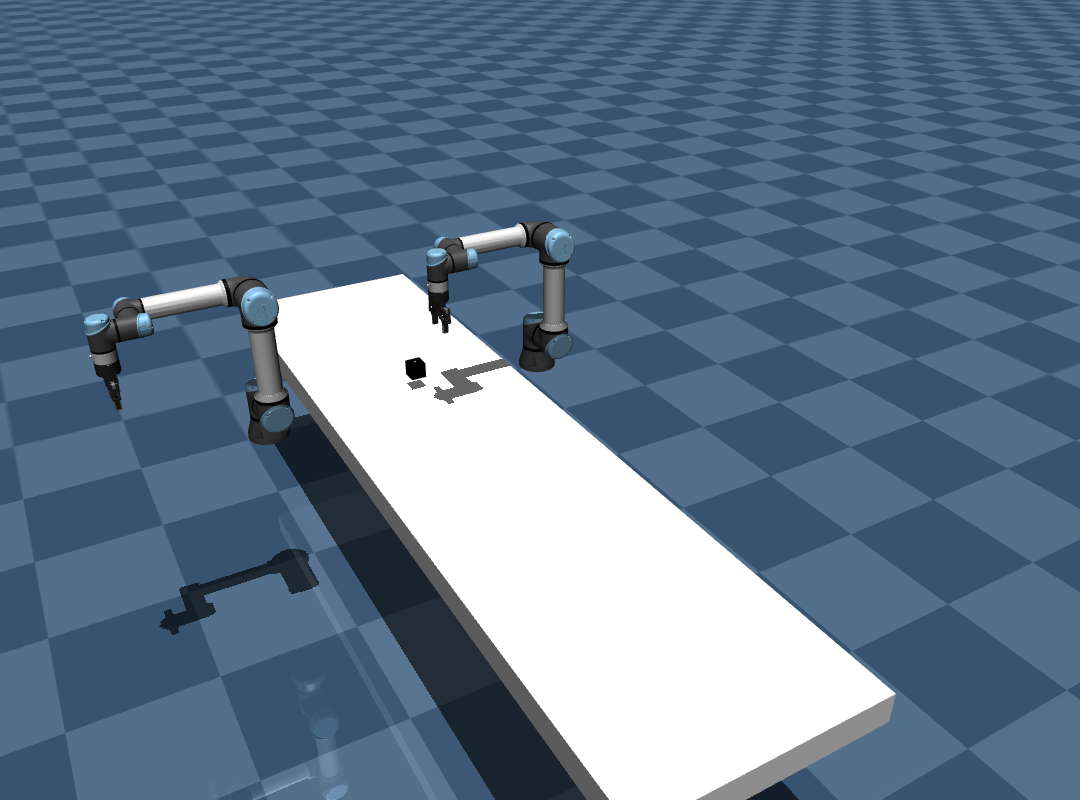

In [41]:
## Render ##
task.render_image(cam_id = 5)

## Create SimRobots

In [42]:
import importlib
import rocobench.envs.robot as Robot

<module 'rocobench.envs.robot' from '/home/adityadutt/Desktop/robot-collab-v2/rocobench/envs/robot.py'>

In [52]:
importlib.reload(Robot)

ur5e_sim = Robot.SimRobot(task.physics,
              "ur5e1",  #   task_robots["ur5e"]["robot_type"], #name,
              task.robot_configs["ur5e"],
              '/home/adityadutt/curobo/src/curobo/content/assets/robot/ur_description/ur5e_new.urdf',
              '/home/adityadutt/curobo/src/curobo/content/configs/robot/ur5e_new.yml',
              task.model)

# panda_sim = SimRobot(task.physics,
#                      task_robots["panda"]["robot_type"], 
#                      task.robot_configs["panda"],
#                      '/home/adityadutt/curobo/src/curobo/content/assets/robot/franka_description/panda.urdf',
#                      '/home/adityadutt/curobo/src/curobo/content/configs/robot/panda.yml',
#                      task.model)

In [53]:
ur5e_sim.initalize_ik(task.physics, check_world_collision=False)
ur5e_sim.initialize_motion_planner(task.physics, check_world_collision=True)

In [54]:
# ur5e_sim.collision_world.get_as_class().save_world_as_mesh("ur5e_mesh.obj")

In [62]:
result = ur5e_sim.solve_ik(task.physics, np.array([-0.5, 0.5, 0.5]))

print(result)

None


In [57]:
# task.physics.named.data.xquat["ur5e/ur5e_0_robotiq_gripper"]

## Generate Trajectories

In [63]:
## Plan a trajectory to pick up the box

## Pre-grasp pose
pre_grasp_pose = task.physics.named.data.qpos["box_free"]

_, pre_grasp_traj = ur5e_sim.plan(
    task.physics, 
    pre_grasp_pose[:3] + np.array([0, 0, 0.5]),
    start_state=task.physics.data.qpos[ur5e_sim.joint_idxs_in_qpos],
    time_dilation=0.1
)

## Handover Position
handover_pose = np.array([pre_grasp_pose[0], pre_grasp_pose[1], pre_grasp_pose[2] + 0.2, 
                           0, 0.7071068, 0, 0.7071068 ]) # 90 deg facing horizontally

_, handover_traj = ur5e_sim.plan(
    task.physics, 
    handover_pose[:3], 
    start_state=pre_grasp_traj[-1].copy(),
    time_dilation=0.1
)


TypeError: 'NoneType' object is not subscriptable

In [ ]:
pre_grasp_pose, handover_pose

(array([-0.5,  0.5,  0.1,  1. ,  0. ,  0. ,  0. ]),
 array([-0.5      ,  0.5      ,  0.3      ,  0.       ,  0.7071068,
         0.       ,  0.7071068]))

In [ ]:
pre_grasp_traj.shape, handover_traj.shape

((781, 6), (310, 6))

In [ ]:
trajectory = np.concatenate([pre_grasp_traj, handover_traj], axis=0)
grasp_idx = len(pre_grasp_traj) - 1
trajectory.shape

(1091, 6)

In [ ]:
task.physics.named.model.eq_active

FieldIndexer(eq_active):
0                   ur5_box [0]
1 panda//unnamed_equality_0 [1]
2  ur5e//unnamed_equality_0 [1]
3  ur5e//unnamed_equality_1 [1]
4  ur5e//unnamed_equality_2 [1]

## Visualize Trajectory

In [29]:
frames = []
ctrls=[]
duration = 10
framerate = 30
control_rate = 0.05
task.physics.reset()  # Reset state and time

while task.physics.data.time < duration:
  #target_pose=physics.named.data.xpos[target_body_top]
  #result=panda1.solve_ik(physics,target_pos=target_pose)
  #ctrl=panda1.map_qpos_to_joint_ctrl(result.qpos)
  t0 = task.physics.data.time

  idx = int(t0 / control_rate)
  if idx > len(trajectory) - 1:
    idx = len(trajectory) - 1
  
  if idx == grasp_idx:
    task.physics.named.model.eq_active["ur5_box"] = 1

  task.physics.data.ctrl[ur5e_sim.joint_idxs_in_ctrl] = trajectory[idx]
  # physics.data.ctrl=ctrl
  #print(ctrl)
  while task.physics.data.time - t0< control_rate:
  #print(physics.data.ctrl)
    task.physics.step()
    if len(frames) < task.physics.data.time * framerate:
      pixels = task.physics.render(camera_id=5, width=800,height=800)
      frames.append(pixels)
display_video(frames, framerate)

## Multi-Arm Planner

In [15]:
ur5e1 = Robot.SimRobot(task.physics,
              "ur5e1", #name,
              task.robot_configs["ur5e"].copy(),
              '/home/adityadutt/curobo/src/curobo/content/assets/robot/ur_description/ur5e_new.urdf',
              '/home/adityadutt/curobo/src/curobo/content/configs/robot/ur5e_new.yml',
              task.model)

ur5e2 = Robot.SimRobot(task.physics,
              "ur5e2", #name,
              task.robot_configs["ur5e"].copy(),
              '/home/adityadutt/curobo/src/curobo/content/assets/robot/ur_description/ur5e_new.urdf',
              '/home/adityadutt/curobo/src/curobo/content/configs/robot/ur5e_new.yml',
              task.model)

In [37]:
import rocobench.curobo_multi_arm as CuroboMultiArm
import rocobench.envs.world_config as W
importlib.reload(W)
importlib.reload(CuroboMultiArm)


<module 'rocobench.curobo_multi_arm' from '/home/adityadutt/Desktop/robot-collab-v2/rocobench/curobo_multi_arm.py'>

In [38]:
task.physics.named.data.xpos

FieldIndexer(xpos):
                                  x         y         z         
 0                        world [ 0         0         0       ]
 1                        table [ 0         0.5       0       ]
 2                    table_top [ 0         0.5       0.1     ]
 3                       ur5e1/ [-0.5      -0.05      0.1     ]
 4            ur5e1/ur5e_0_base [-0.5      -0.05      0.1     ]
 5   ur5e1/ur5e_0_shoulder_link [-0.5      -0.05      0.263   ]
 6  ur5e1/ur5e_0_upper_arm_link [-0.366    -0.0166    0.263   ]
 7    ur5e1/ur5e_0_forearm_link [-0.504    -0.00534   0.686   ]
 8    ur5e1/ur5e_0_wrist_1_link [-0.599     0.375     0.694   ]
 9    ur5e1/ur5e_0_wrist_2_link [-0.476     0.406     0.694   ]
10    ur5e1/ur5e_0_wrist_3_link [-0.5       0.503     0.693   ]
11 ur5e1/ur5e_0_robotiq_gripper [-0.5       0.502     0.603   ]
12     ur5e1/robotiq_base_mount [-0.5       0.502     0.596   ]
13              ur5e1/2f85_base [-0.5       0.502     0.592   ]
14           ur5e1/

In [39]:
multiarm_planner = CuroboMultiArm.MultiArmCurobo(task.physics, task.model, {"ur5e1": ur5e1, "ur5e2": ur5e2})

In [40]:
multiarm_planner.initialize_motion_planner(task.physics)

In [41]:
task.physics.named.data.xpos

FieldIndexer(xpos):
                                  x         y         z         
 0                        world [ 0         0         0       ]
 1                        table [ 0         0.5       0       ]
 2                    table_top [ 0         0.5       0.1     ]
 3                       ur5e1/ [-0.5      -0.05      0.1     ]
 4            ur5e1/ur5e_0_base [-0.5      -0.05      0.1     ]
 5   ur5e1/ur5e_0_shoulder_link [-0.5      -0.05      0.263   ]
 6  ur5e1/ur5e_0_upper_arm_link [-0.366    -0.0166    0.263   ]
 7    ur5e1/ur5e_0_forearm_link [-0.504    -0.00534   0.686   ]
 8    ur5e1/ur5e_0_wrist_1_link [-0.599     0.375     0.694   ]
 9    ur5e1/ur5e_0_wrist_2_link [-0.476     0.406     0.694   ]
10    ur5e1/ur5e_0_wrist_3_link [-0.5       0.503     0.693   ]
11 ur5e1/ur5e_0_robotiq_gripper [-0.5       0.502     0.603   ]
12     ur5e1/robotiq_base_mount [-0.5       0.502     0.596   ]
13              ur5e1/2f85_base [-0.5       0.502     0.592   ]
14           ur5e1/

In [42]:
# multiarm_planner.collision_world.save_world_mesh("multiarm_mesh.obj")

In [88]:
task.physics.reset(0)
multiarm_traj = multiarm_planner.plan(task.physics, {"ur5e1": [-0.1, 0.5, 0.6, 0, 1, 0, 0], "ur5e2": [-0.5, 0.5, 0.6, 0, 0.707, 0, 0.707]}, time_dilation = 0.25)

In [89]:
multiarm_traj.shape, ur5e1.joint_idxs_in_ctrl, ur5e2.joint_idxs_in_ctrl

((257, 12), [1, 2, 3, 4, 5, 6], [9, 10, 11, 12, 13, 14])

In [85]:
print(multiarm_traj[0:51, :])

[[-1.5707999e+00 -1.5707999e+00  1.5707999e+00 -1.5707999e+00
  -1.5707999e+00  0.0000000e+00 -1.5707999e+00 -1.5707999e+00
   1.5707999e+00 -1.5707999e+00 -1.5707999e+00  0.0000000e+00]
 [-1.5707999e+00 -1.5707999e+00  1.5707999e+00 -1.5707999e+00
  -1.5707999e+00  0.0000000e+00 -1.5707999e+00 -1.5707999e+00
   1.5707999e+00 -1.5707999e+00 -1.5707999e+00  0.0000000e+00]
 [-1.5707999e+00 -1.5707999e+00  1.5707999e+00 -1.5707999e+00
  -1.5707999e+00  0.0000000e+00 -1.5707999e+00 -1.5707999e+00
   1.5707999e+00 -1.5707999e+00 -1.5707999e+00  0.0000000e+00]
 [-1.5707999e+00 -1.5707999e+00  1.5707999e+00 -1.5707999e+00
  -1.5707999e+00  0.0000000e+00 -1.5707999e+00 -1.5707999e+00
   1.5707999e+00 -1.5707999e+00 -1.5707999e+00  0.0000000e+00]
 [-1.5707999e+00 -1.5707999e+00  1.5707999e+00 -1.5707999e+00
  -1.5707999e+00  0.0000000e+00 -1.5707999e+00 -1.5707999e+00
   1.5707999e+00 -1.5707999e+00 -1.5707999e+00  0.0000000e+00]
 [-1.5679892e+00 -1.5702370e+00  1.5701352e+00 -1.5705607e+00
  -

In [90]:
frames = []
ctrls=[]
duration = 10
framerate = 20
control_rate = 0.02
task.physics.reset(0)  # Reset state and time

while task.physics.data.time < duration:

  t0 = task.physics.data.time

  idx = int(t0 / control_rate)
  if idx > len(multiarm_traj) - 1:
    idx = len(multiarm_traj) - 1
  
#   if idx == grasp_idx:
#     task.physics.named.model.eq_active["ur5_box"] = 1

  task.physics.data.ctrl[ur5e1.joint_idxs_in_ctrl + ur5e2.joint_idxs_in_ctrl] = multiarm_traj[idx]

  while task.physics.data.time - t0< control_rate:
    task.physics.step()
    if len(frames) < task.physics.data.time * framerate:
      pixels = task.physics.render(camera_id=5, width=800,height=800)
      frames.append(pixels)
display_video(frames, framerate)

In [56]:
display_video(frames, framerate/5)